# Figure 6 - Brief analysis of Transcription Factor binding Sites

## Goals:
1. Characterize cell cycle nature of cycling transcription factors, prevelence of PTR
2. Characterize which of these are associated with genes and whether those genes are cell cycle (cross-reference with transcription-story)


In [18]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from src.TranscriptionFactorProcessor import TranscriptionFactorProcessor

# Initialize and run comprehensive analysis
analyzer = TranscriptionFactorProcessor(output_dir='output/draft4_run/')
full_results = analyzer.build_comprehensive_dataframe(include_ptr=True)

# Access different aspects
gene_associations = full_results['associated_genes']  # "CLB5,THI22" format
ptr_values = full_results[['ptr']]
association_stats = analyzer.get_association_summary()


Building comprehensive dataframe with gene associations...
Loading TF binding datasets...
Number of total factors profiled by Rossi:  319
Number of TFs selected by GO terms (GO:0016563,GO:0043565):  166
Number of TFs with Rossi binding sites:  76
   of these, Kelliher cell-cycle TFS:  12
Found 2793 high-confidence binding sites for 76 cell cycle TFs
Preparing binding site coordinates...
Prepared 2793 binding sites with ±40bp windows
Loading and processing chromatin data...
Processing site 1/2793


In [24]:
from pipeline.chromatin_metrics_processor import ChromatinMetricsProcessor

chromatin_processor = ChromatinMetricsProcessor('output/draft4_run/')
chromatin_processor.load_and_assign_saved_metrics()
promoter_values = chromatin_processor.deconvolved_chromatin_metrics['promoter_occupancy'].dropna().values.flatten()
threshold = np.quantile(promoter_values, q=0.95)

In [286]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_tf_boxplots(ptr_values, column='ptr', figsize=(6, 6), 
                     title="Cell cycle transcription factor binding", 
                     show_outliers=False, 
                     show_points=True, 
                     point_color='#aaa', point_alpha=1.0, 
                     point_size=1, jitter_width=0.1):
    """
    Plot box plots for specified column values grouped by transcription factor (tf).
    """

    median_ptrs = ptr_values.reset_index()[['tf', 'ptr']].groupby('tf').median()\
        .sort_values('ptr')
    
    # Count number of sites
    num_sites = ptr_values.dropna().reset_index()[['tf', 'ptr']]\
        .groupby('tf').count()
    num_sites = num_sites.sort_values('ptr').rename(columns={'ptr': 'num_total'})
    
    # Count number of cycling sites
    cycling_counts = ptr_values[ptr_values > threshold].dropna().reset_index()[['tf', 'ptr']]\
        .groupby('tf').count()
    cycling_counts = cycling_counts.sort_values('ptr').rename(columns={'ptr': 'num_cycling'})

    ptr_counts_df = cycling_counts.join(num_sites)
    ptr_counts_df = ptr_counts_df.sort_values(['num_cycling', 'num_total'])

    # Sort by number of cycling counts
    sorted_tf_index = ptr_counts_df.index
    
    # Prepare data for box plots
    data_list = []
    tf_names = []
    
    for tf_name in sorted_tf_index:
        clean_data = ptr_values.loc[tf_name][column].dropna().values
        
        if len(clean_data) > 0:  # Only include if there's data
            data_list.append(clean_data)
            tf_names.append(tf_name)

    # Create the box plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create box plots
    color=plt.cm.Oranges(0.35)
    
    # Add jittered scatter points if requested
    if show_points:
        np.random.seed(42)  # For reproducible jitter
        for i, data in enumerate(data_list):
            # Create jittered y-positions
            y_pos = i + 1  # Box positions are 1-indexed
            y_jitter = np.random.uniform(-jitter_width, jitter_width, len(data))
            y_positions = y_pos + y_jitter
            
            # Plot the scattered points
            ax.scatter(data, y_positions, alpha=point_alpha, 
                      color=point_color, s=point_size, zorder=0)

    box_plot = ax.boxplot(data_list, labels=tf_names, patch_artist=True, 
                         showfliers=show_outliers, vert=False)
    
    # Color the boxes
    for patch in box_plot['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
    
    # Customize the plot
    ax.set_xlabel(f'{column.upper()} Value', fontsize=12)
    ax.set_ylabel('Transcription Factor', fontsize=12)
    ax.set_title(title, fontsize=21, fontweight='demi', pad=13)
    
    # Add some statistics as text
    n_factors = len(tf_names)
    total_sites = sum(len(data) for data in data_list)
    
    tick_names = []
    for i, tf_name in enumerate(sorted_tf_index):
        tick_names.append(tf_name)
        
        num_total_sites = num_sites.loc[tf_name].num_total
        num_cycling_sites = cycling_counts.loc[tf_name].num_cycling
        tick_name = f"n= {num_total_sites} ({num_cycling_sites})"
        
        y_position = i+1
        x = 0.45
        ax.text(x, y_position, tick_name, ha='left', va='center')

    ax.set_yticklabels(tick_names)
    ax.set_ylim(0, len(sorted_tf_index)+1)
    ax.set_xticks(np.arange(1, 5, 0.5))
    ax.set_xlim(0.35, 3.1)
    plt.tight_layout()
        
    return fig, ax

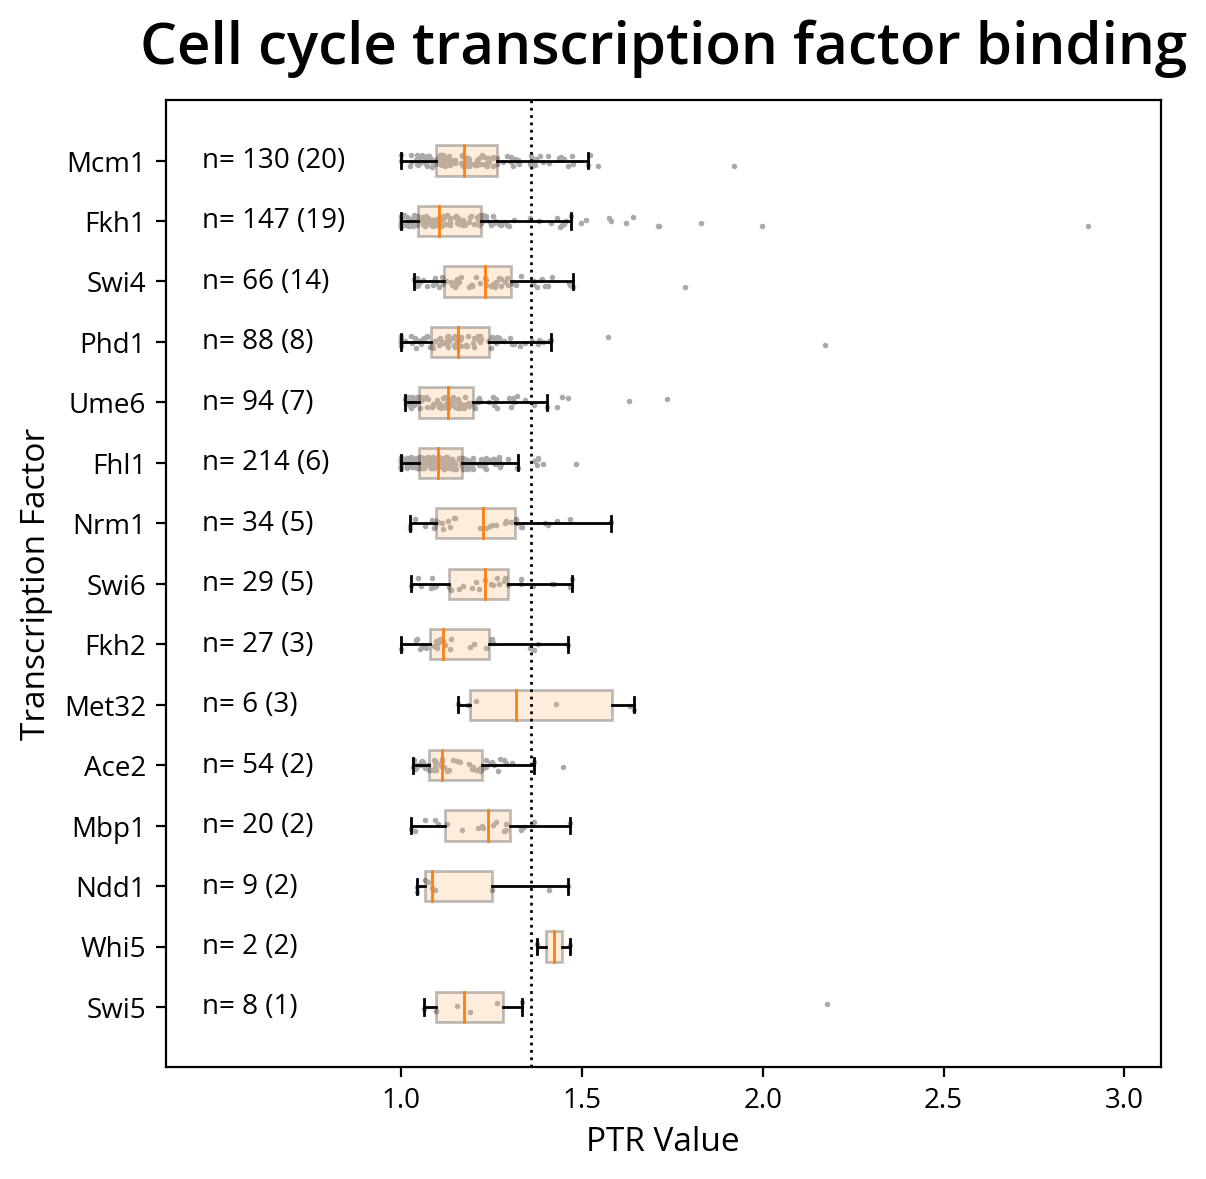

In [287]:
_ = plot_tf_boxplots(ptr_values)

plt.axvline(threshold, lw=1, ls='dotted', c='black')
